# GNN Trajectory Class Classifier

This notebook builds a Graph Neural Network to classify subjects into irritability trajectory classes.

**Graph construction:**  
- Each subject is a **node** with features: `[intercept, slope]`  
- Edges connect subjects that are **similar** in trajectory space (k-NN graph)  
- The GNN learns to classify nodes into trajectory classes 0–4


In [ ]:
# Install dependencies if needed
# !pip install torch torch-geometric scikit-learn pandas numpy matplotlib
# For torch-geometric, see: https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html

In [2]:
# Ensure that we are using the correct host
import socket
try:
    assert "gpu" in socket.gethostname()
    print(f"Running on {socket.gethostname()}. All is good!")
except:
    raise RuntimeError(f"Be sure to run on GPU! You are currently running on {socket.gethostname()}")

Running on gpu14.storrs.hpc.uconn.edu. All is good!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
from torch_geometric.utils import to_undirected

from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("PyTorch version:", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

PyTorch version: 2.5.1
Using device: cuda


## 1. Load Data

In [3]:
# ── UPDATE THIS PATH ──────────────────────────────────────────────────────────
CSV_PATH = "/home/rif17002/honors_thesis/Clinical/trajectory_analysis_output/trajectory_classes.csv"
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
print(df.shape)
print(df["class"].value_counts().sort_index())
df.head()

(11511, 5)
class
0    3687
1    3232
2     734
3    1279
4    2579
Name: count, dtype: int64


,id,intercept,slope,class,class_prob
0,NDAR_INV003RTV85,0.000000,0.0,0,0.999999
1,NDAR_INV005V6D2C,0.000000,0.0,0,0.999999
2,NDAR_INV007W6H7B,0.000000,0.0,0,0.999999
3,NDAR_INV00BD7VDC,0.833333,-0.5,1,0.397151
4,NDAR_INV00CY2MDM,5.000000,-0.5,3,0.999969


## 2. Build Node Features & Labels

In [4]:
# ── OPTIONAL: add more subject-level features here (e.g. age, sex, baseline scores)
FEATURE_COLS = ["intercept", "slope"]

df = df.dropna(subset=FEATURE_COLS + ["class"]).reset_index(drop=True)

scaler = StandardScaler()
X = scaler.fit_transform(df[FEATURE_COLS].values).astype(np.float32)
y = df["class"].values.astype(np.int64)

num_classes = len(np.unique(y))
print(f"Nodes: {len(X)}, Features: {X.shape[1]}, Classes: {num_classes}")

Nodes: 11511, Features: 2, Classes: 5


## 3. Build k-NN Graph

We connect each subject to their K nearest neighbors based on trajectory features.
- Larger K → denser graph, more smoothing
- Smaller K → sparser graph, finer distinctions


In [5]:
K_NEIGHBORS = 10  # tune this (try 5, 10, 15, 20)

# Build sparse adjacency matrix in COO format
A = kneighbors_graph(X, n_neighbors=K_NEIGHBORS, mode='connectivity', include_self=False)
cx = A.tocoo()

edge_index = torch.tensor(np.vstack([cx.row, cx.col]), dtype=torch.long)
edge_index = to_undirected(edge_index)  # make symmetric

print(f"Edges: {edge_index.shape[1]} (undirected)")

# Build PyG Data object
data = Data(
    x=torch.tensor(X, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.long)
)
print(data)

Edges: 200456 (undirected)
Data(x=[11511, 2], edge_index=[2, 200456], y=[11511])


## 4. Train / Val / Test Splits

In [6]:
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
SEED        = 42

n = len(y)
idx = np.arange(n)

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_RATIO, random_state=SEED)
train_val_idx, test_idx = next(sss.split(idx, y))

val_size_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size_adjusted, random_state=SEED)
train_idx, val_idx = next(sss2.split(train_val_idx, y[train_val_idx]))
train_idx = train_val_idx[train_idx]
val_idx   = train_val_idx[val_idx]

def make_mask(indices, n):
    mask = torch.zeros(n, dtype=torch.bool)
    mask[indices] = True
    return mask

data.train_mask = make_mask(train_idx, n)
data.val_mask   = make_mask(val_idx, n)
data.test_mask  = make_mask(test_idx, n)

print(f"Train: {data.train_mask.sum().item()} | Val: {data.val_mask.sum().item()} | Test: {data.test_mask.sum().item()}")

Train: 8057 | Val: 1727 | Test: 1727


## 5. Define GNN Models

Three architectures are available:
- **GCN** – Graph Convolutional Network (Kipf & Welling, 2017)
- **GraphSAGE** – Inductive representation learning
- **GAT** – Graph Attention Network (with edge attention weights)


In [7]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.4):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x


class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.4):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x


class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.4):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        self.conv3 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x


print("Model definitions ready.")

Model definitions ready.


## 6. Training Loop

In [8]:
def train_model(model, data, epochs=300, lr=0.005, weight_decay=5e-4, patience=30):
    """
    Train a GNN with early stopping on validation loss.
    Returns trained model + history dict.
    """
    model = model.to(device)
    data  = data.to(device)

    # Class weights to handle imbalanced classes
    class_counts = np.bincount(y[train_idx], minlength=num_classes)
    class_weights = torch.tensor(1.0 / (class_counts + 1e-6), dtype=torch.float).to(device)
    class_weights = class_weights / class_weights.sum() * num_classes  # normalize

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # ── Evaluate ──
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask]).item()

            train_pred = out[data.train_mask].argmax(dim=1)
            val_pred   = out[data.val_mask].argmax(dim=1)
            train_acc  = (train_pred == data.y[data.train_mask]).float().mean().item()
            val_acc    = (val_pred   == data.y[data.val_mask]).float().mean().item()

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        # ── Early stopping ──
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stop at epoch {epoch}")
                break

        if epoch % 50 == 0:
            print(f"  Epoch {epoch:4d} | train loss {loss.item():.4f} acc {train_acc:.3f} | val loss {val_loss:.4f} acc {val_acc:.3f}")

    model.load_state_dict(best_state)
    return model, history


def evaluate_model(model, data):
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
        true = data.y[data.test_mask].cpu().numpy()
    acc = (pred == true).mean()
    print(f"\nTest Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(true, pred, zero_division=0))
    return pred, true


def plot_training(history, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"],   label="Val")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"],   label="Val")
    axes[1].set_title("Accuracy")
    axes[1].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


print("Training utilities defined.")

Training utilities defined.


## 7. Train & Compare All Three Models


Training GCN
  Epoch   50 | train loss 0.5219 acc 0.832 | val loss 0.4705 acc 0.815
  Epoch  100 | train loss 0.2631 acc 0.925 | val loss 0.2072 acc 0.915
  Epoch  150 | train loss 0.1449 acc 0.975 | val loss 0.1220 acc 0.971
  Epoch  200 | train loss 0.1267 acc 0.975 | val loss 0.0960 acc 0.969
  Epoch  250 | train loss 0.0873 acc 0.980 | val loss 0.0776 acc 0.978
  Epoch  300 | train loss 0.0912 acc 0.979 | val loss 0.0701 acc 0.975
  Epoch  350 | train loss 0.0768 acc 0.986 | val loss 0.0605 acc 0.985
  Epoch  400 | train loss 0.0667 acc 0.990 | val loss 0.0541 acc 0.988


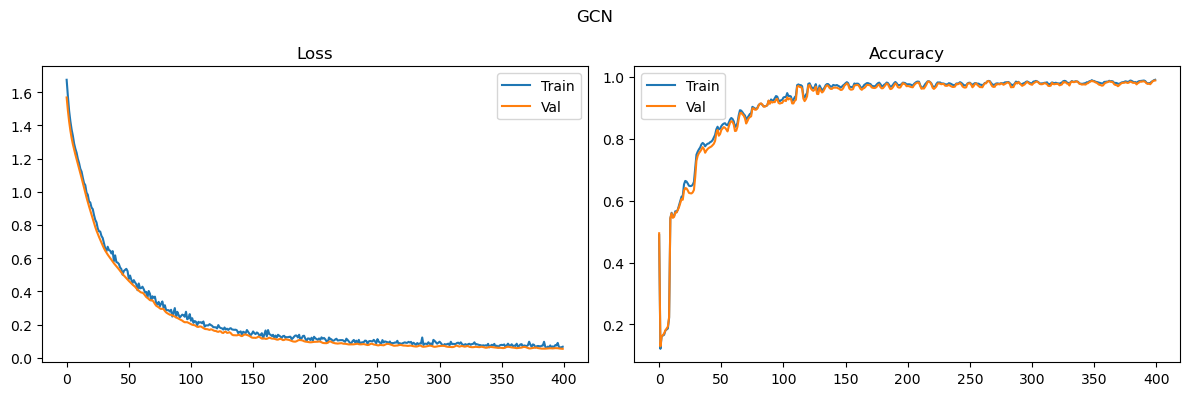


Test Accuracy: 0.9884

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       553
           1       1.00      0.97      0.98       485
           2       0.98      0.98      0.98       110
           3       0.97      0.99      0.98       192
           4       0.97      1.00      0.99       387

    accuracy                           0.99      1727
   macro avg       0.98      0.99      0.99      1727
weighted avg       0.99      0.99      0.99      1727


Training GraphSAGE
  Epoch   50 | train loss 0.1362 acc 0.971 | val loss 0.0966 acc 0.964
  Epoch  100 | train loss 0.0665 acc 0.983 | val loss 0.0563 acc 0.981
  Epoch  150 | train loss 0.0691 acc 0.994 | val loss 0.0349 acc 0.990
  Epoch  200 | train loss 0.0379 acc 0.996 | val loss 0.0287 acc 0.995
  Epoch  250 | train loss 0.0467 acc 0.994 | val loss 0.0298 acc 0.994
  Epoch  300 | train loss 0.0337 acc 0.997 | val loss 0.0268 acc 0.995
  Early stop at ep

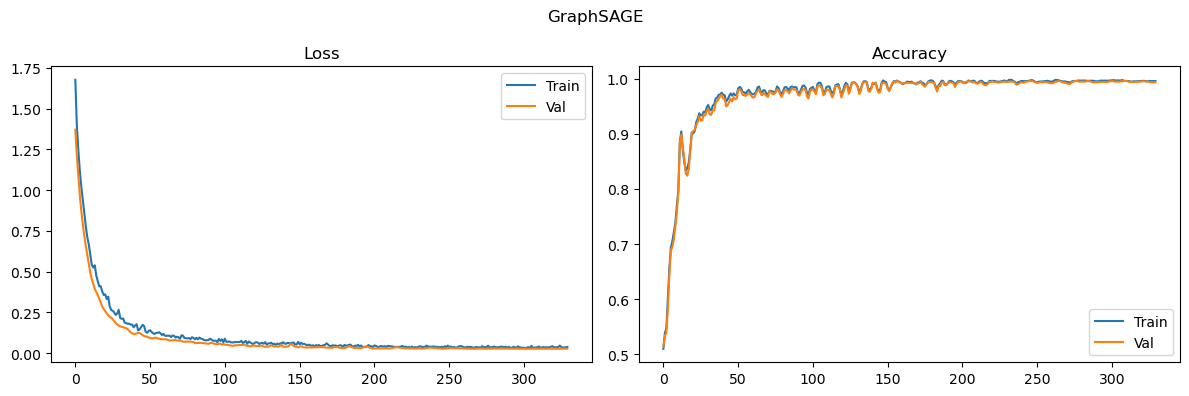


Test Accuracy: 0.9936

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       553
           1       1.00      0.99      0.99       485
           2       0.99      0.98      0.99       110
           3       0.97      1.00      0.98       192
           4       0.99      0.99      0.99       387

    accuracy                           0.99      1727
   macro avg       0.99      0.99      0.99      1727
weighted avg       0.99      0.99      0.99      1727


Training GAT
  Epoch   50 | train loss 0.1109 acc 0.981 | val loss 0.1215 acc 0.979
  Epoch  100 | train loss 0.0718 acc 0.984 | val loss 0.0627 acc 0.980
  Epoch  150 | train loss 0.0525 acc 0.990 | val loss 0.0654 acc 0.986
  Early stop at epoch 170


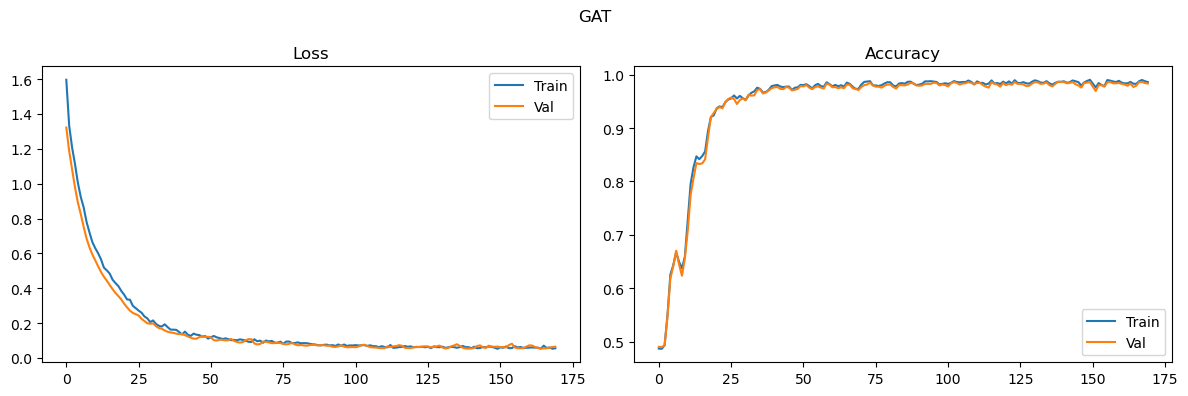


Test Accuracy: 0.9849

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       553
           1       0.99      0.97      0.98       485
           2       0.93      0.98      0.96       110
           3       0.96      0.98      0.97       192
           4       0.98      0.98      0.98       387

    accuracy                           0.98      1727
   macro avg       0.97      0.98      0.98      1727
weighted avg       0.99      0.98      0.98      1727



In [9]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
HIDDEN  = 64
DROPOUT = 0.4
EPOCHS  = 400
LR      = 0.005

in_ch  = data.num_node_features
out_ch = num_classes

model_configs = {
    "GCN":       GCN(in_ch, HIDDEN, out_ch, dropout=DROPOUT),
    "GraphSAGE": GraphSAGE(in_ch, HIDDEN, out_ch, dropout=DROPOUT),
    "GAT":       GAT(in_ch, HIDDEN, out_ch, dropout=DROPOUT),
}

results = {}

for name, model in model_configs.items():
    print(f"\n{'='*50}")
    print(f"Training {name}")
    print('='*50)
    trained_model, history = train_model(model, data, epochs=EPOCHS, lr=LR)
    plot_training(history, title=name)
    pred, true = evaluate_model(trained_model, data)
    results[name] = {"model": trained_model, "history": history, "pred": pred, "true": true}

## 8. Confusion Matrix for Best Model

Best model: GraphSAGE


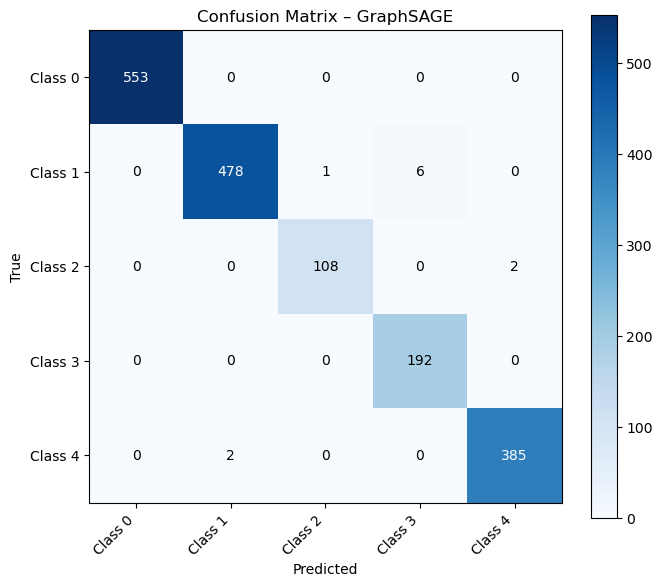

In [10]:
# ── Pick the model with the best test accuracy ────────────────────────────────
best_name = max(results, key=lambda n: (results[n]["pred"] == results[n]["true"]).mean())
print(f"Best model: {best_name}")

pred = results[best_name]["pred"]
true = results[best_name]["true"]

cm = confusion_matrix(true, pred)
class_names = [f"Class {i}" for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix – {best_name}")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()

## 9. Save Best Model & Predictions

In [11]:
OUTPUT_DIR = "/home/rif17002/honors_thesis/Clinical/trajectory_analysis_output"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save model weights
torch.save(
    results[best_name]["model"].state_dict(),
    os.path.join(OUTPUT_DIR, f"gnn_{best_name.lower()}_best.pt")
)

# Save full predictions on ALL nodes
best_model = results[best_name]["model"].to(device)
best_model.eval()
data_dev = data.to(device)

with torch.no_grad():
    logits = best_model(data_dev.x, data_dev.edge_index)
    all_preds = logits.argmax(dim=1).cpu().numpy()
    all_probs = F.softmax(logits, dim=1).cpu().numpy()

out_df = df[["id", "class"]].copy()
out_df["gnn_predicted_class"] = all_preds
out_df["gnn_max_prob"] = all_probs.max(axis=1)

# Add per-class probabilities
for c in range(num_classes):
    out_df[f"gnn_prob_class{c}"] = all_probs[:, c]

out_path = os.path.join(OUTPUT_DIR, "gnn_predictions.csv")
out_df.to_csv(out_path, index=False)
print(f"Predictions saved to: {out_path}")
out_df.head()

Predictions saved to: /home/rif17002/honors_thesis/Clinical/trajectory_analysis_output/gnn_predictions.csv


,id,class,gnn_predicted_class,gnn_max_prob,gnn_prob_class0,gnn_prob_class1,gnn_prob_class2,gnn_prob_class3,gnn_prob_class4
0,NDAR_INV003RTV85,0,0,0.999068,9.990682e-01,3.537763e-08,7.458012e-08,1.045909e-07,0.000932
1,NDAR_INV005V6D2C,0,0,0.999068,9.990682e-01,3.537763e-08,7.458012e-08,1.045909e-07,0.000932
2,NDAR_INV007W6H7B,0,0,0.999068,9.990681e-01,3.537830e-08,7.458637e-08,1.045921e-07,0.000932
3,NDAR_INV00BD7VDC,1,1,0.851752,2.421096e-04,8.517517e-01,6.822192e-07,4.479695e-02,0.103209
4,NDAR_INV00CY2MDM,3,3,1.000000,1.401298e-45,2.708990e-12,2.508324e-43,1.000000e+00,0.000000


## 10. Node Embedding Visualization (UMAP / t-SNE)

Visualize the learned GNN embeddings to see how well-separated the classes are.

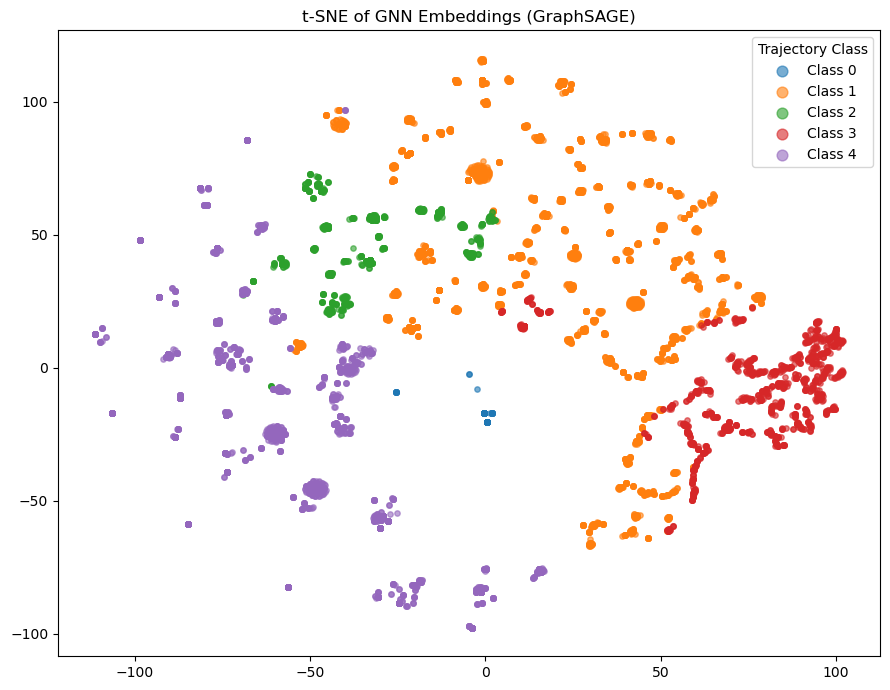

Saved t-SNE plot.


In [12]:
from sklearn.manifold import TSNE

# Extract penultimate layer embeddings
class EmbeddingExtractor(nn.Module):
    """Wraps a GNN and returns hidden embeddings instead of logits."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index):
        # Works for GCN / GraphSAGE (3-layer)
        m = self.model
        x = F.relu(m.conv1(x, edge_index))
        x = F.relu(m.conv2(x, edge_index))
        return x  # penultimate layer


best_model.eval()
extractor = EmbeddingExtractor(best_model).to(device)

with torch.no_grad():
    embeddings = extractor(data_dev.x, data_dev.edge_index).cpu().numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=40)
emb2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(9, 7))
colors = plt.cm.tab10.colors
for c in range(num_classes):
    mask = (y == c)
    plt.scatter(emb2d[mask, 0], emb2d[mask, 1],
                label=f"Class {c}", alpha=0.6, s=15,
                color=colors[c % len(colors)])

plt.title(f"t-SNE of GNN Embeddings ({best_name})")
plt.legend(title="Trajectory Class", markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gnn_tsne_embeddings.png"), dpi=150)
plt.show()
print("Saved t-SNE plot.")